# Lending Club Loan Data Analysis

**Course-end Project 1 | IITK AIML Core: Deep Learning with Keras and TensorFlow**

**Objective:** Build a deep learning model to predict loan default (`not.fully.paid`) using historical Lending Club data (2007–2015).

**Domain:** Finance

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, accuracy_score, recall_score, precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('TensorFlow:', tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow: 2.21.0


In [2]:
df = pd.read_csv('datasets/loan_data.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(10)

Shape: (9578, 14)
Columns: ['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
5,1,credit_card,0.0788,125.13,11.904968,16.98,727,6120.041667,50807,51.0,0,0,0,0
6,1,debt_consolidation,0.1496,194.02,10.714418,4.00,667,3180.041667,3839,76.8,0,0,1,1
7,1,all_other,0.1114,131.22,11.002100,11.08,722,5116.000000,24220,68.6,0,0,0,1
8,1,home_improvement,0.1134,87.19,11.407565,17.25,682,3989.000000,69909,51.1,1,0,0,0
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,0


## 2. Data Quality Check

In [3]:
print(df.info())
print('\nMissing values:', df.isna().sum().sum())
print('\nTarget distribution (not.fully.paid):')
print(df['not.fully.paid'].value_counts())
print(df['not.fully.paid'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None

Missing values: 0

Target distribution (not.fully.paid):
not.fully.paid


,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


## 3. Feature Transformation — Categorical → Numerical

In [4]:
print('Purpose categories:')
print(df['purpose'].value_counts())

# One-hot encode purpose (discrete numerical features)
df_enc = pd.get_dummies(df, columns=['purpose'], drop_first=True, dtype=float)
print('\nShape after encoding:', df_enc.shape)
print('Encoded columns:', [c for c in df_enc.columns if c.startswith('purpose_')])
df_enc.head()

Purpose categories:
purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

Shape after encoding: (9578, 19)
Encoded columns: ['purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_small_business']


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1.0,0.0,0.0,0.0,0.0,0.0


## 4. Exploratory Data Analysis

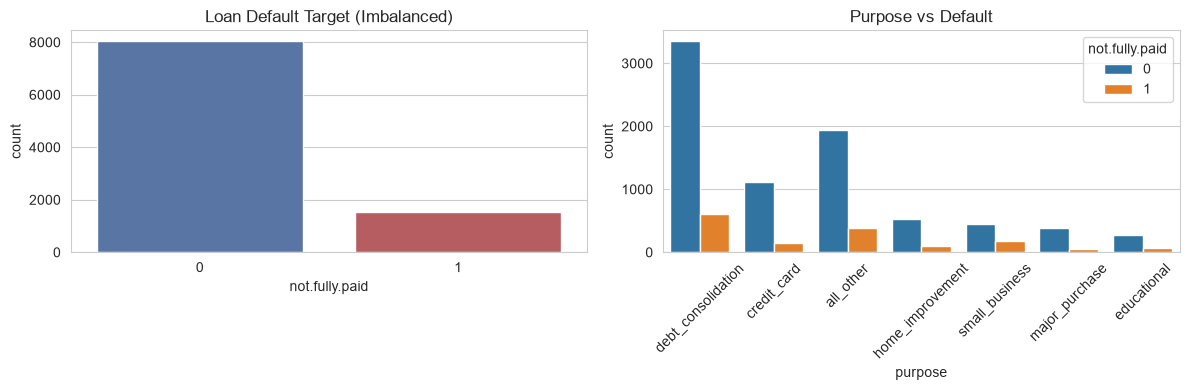

Default rate by purpose:
purpose
small_business        27.79%
educational           20.12%
home_improvement      17.01%
all_other              16.6%
debt_consolidation    15.24%
credit_card           11.57%
major_purchase        11.21%
Name: not.fully.paid, dtype: str


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='not.fully.paid', ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Loan Default Target (Imbalanced)')
sns.countplot(data=df, x='purpose', hue='not.fully.paid', ax=axes[1])
axes[1].set_title('Purpose vs Default')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Default rate by purpose:')
print(df.groupby('purpose')['not.fully.paid'].mean().mul(100).round(2).sort_values(ascending=False).astype(str) + '%')

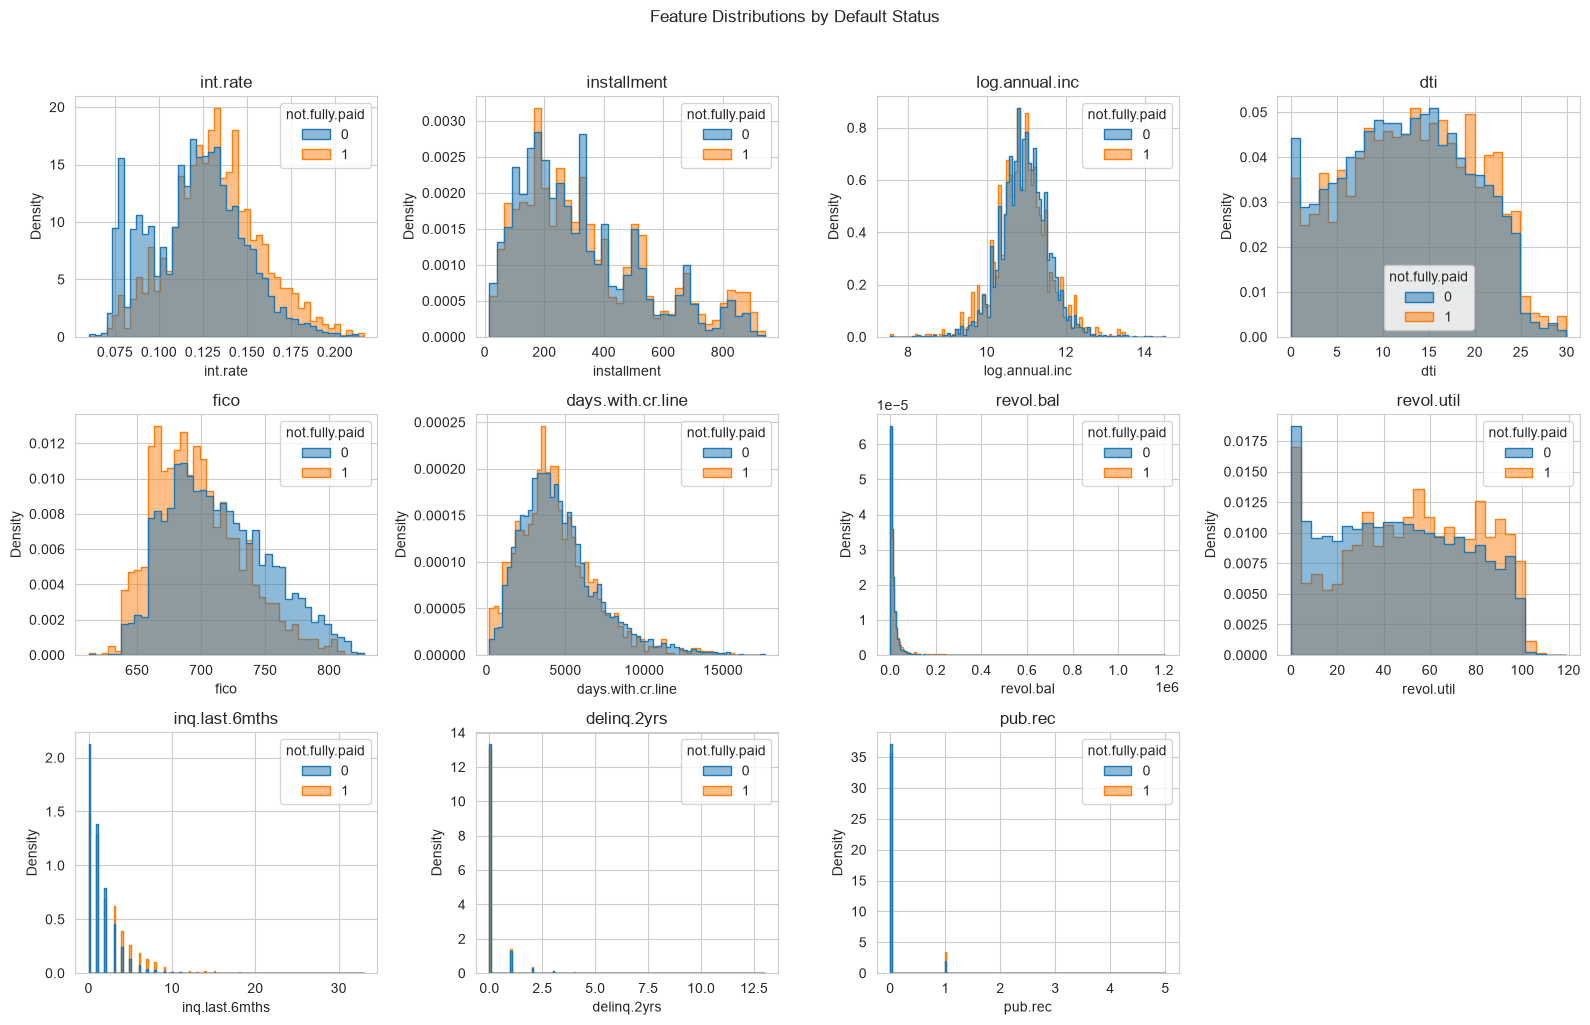

In [6]:
num_feats = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
             'days.with.cr.line', 'revol.bal', 'revol.util',
             'inq.last.6mths', 'delinq.2yrs', 'pub.rec']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.histplot(data=df, x=col, hue='not.fully.paid', ax=axes[i],
                 element='step', stat='density', common_norm=False, alpha=0.5)
    axes[i].set_title(col)
axes[-1].axis('off')
plt.suptitle('Feature Distributions by Default Status', y=1.02)
plt.tight_layout()
plt.show()

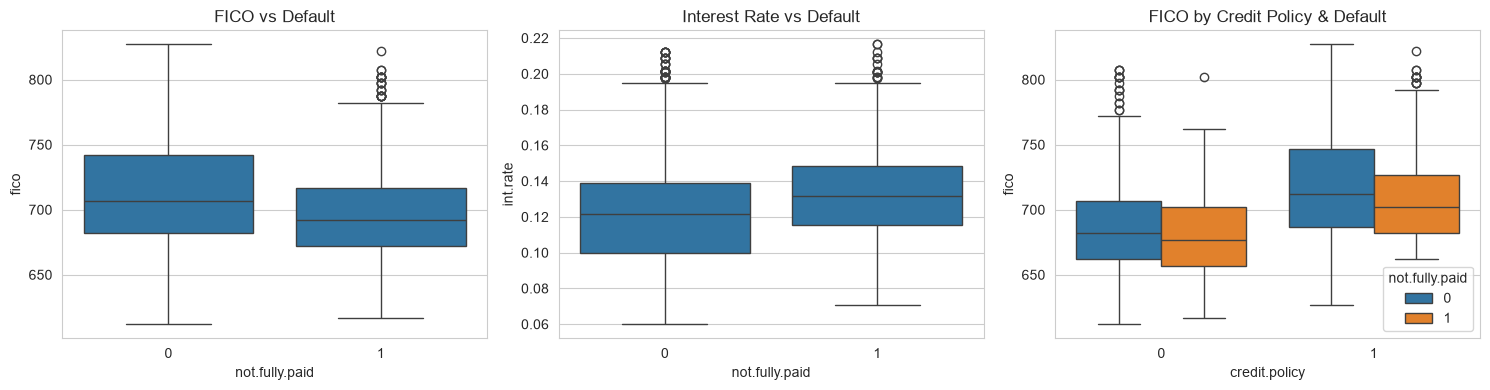

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='not.fully.paid', y='fico', ax=axes[0])
axes[0].set_title('FICO vs Default')
sns.boxplot(data=df, x='not.fully.paid', y='int.rate', ax=axes[1])
axes[1].set_title('Interest Rate vs Default')
sns.boxplot(data=df, x='credit.policy', y='fico', hue='not.fully.paid', ax=axes[2])
axes[2].set_title('FICO by Credit Policy & Default')
plt.tight_layout()
plt.show()

**EDA takeaways:** Dataset is imbalanced (~16% defaults). Higher interest rates and lower FICO scores associate with higher default risk. Purpose (especially small_business / educational) shows elevated default rates.

## 5. Additional Feature Engineering — Drop Strongly Correlated Features

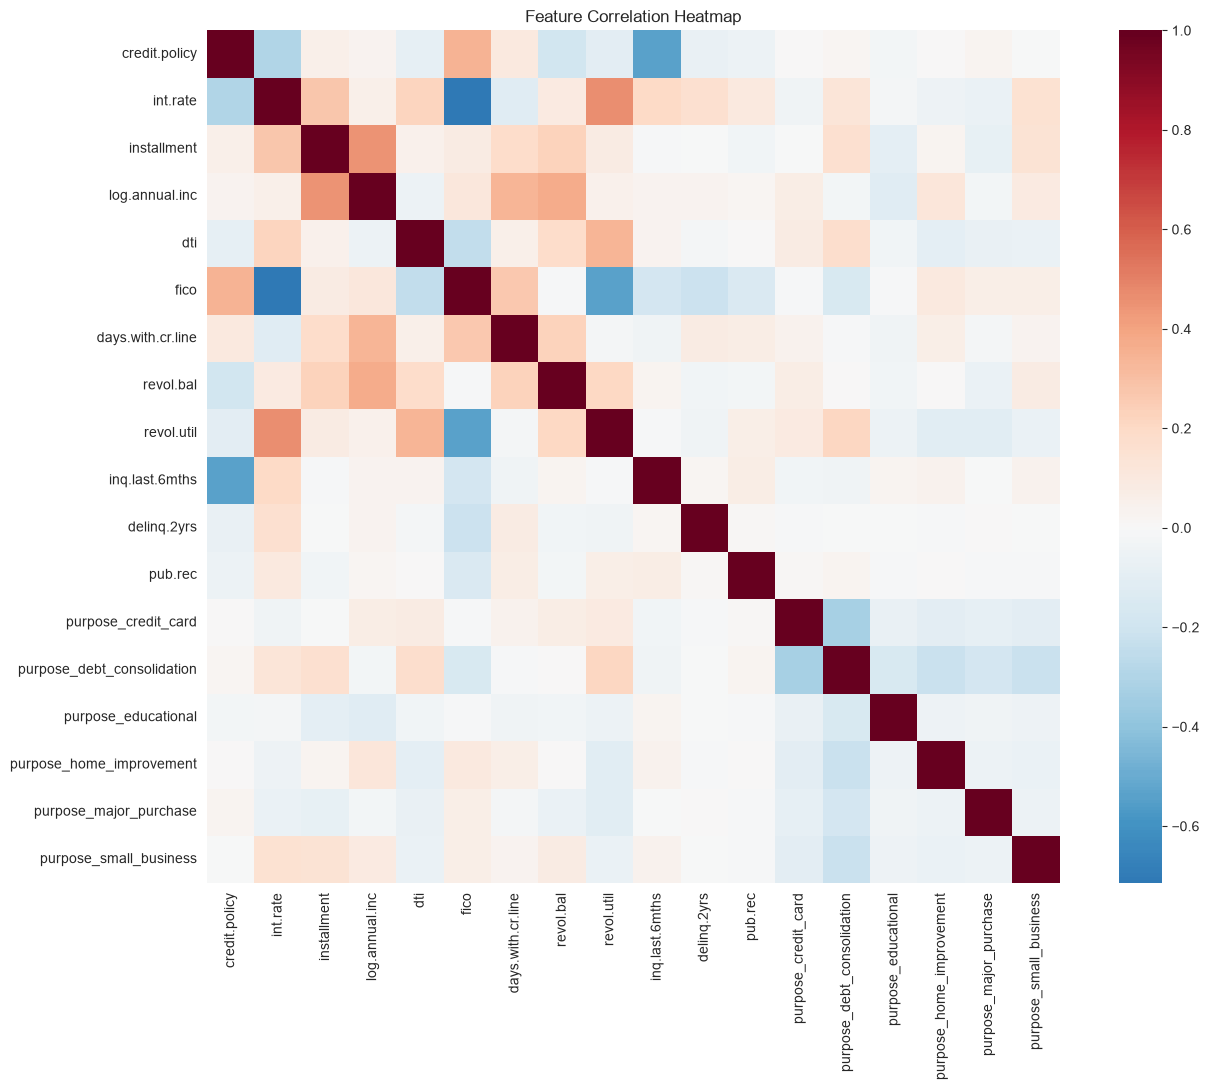

Strongly correlated pairs (|r| > 0.8):

Features dropped due to strong correlation: set()
Remaining shape: (9578, 19)


In [8]:
# Correlation among predictors (exclude target)
X_corr = df_enc.drop(columns=['not.fully.paid'])
corr = X_corr.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Find pairs with |corr| > 0.80
threshold = 0.80
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if abs(upper.loc[row, col]) > threshold
]
print(f'Strongly correlated pairs (|r| > {threshold}):')
for a, b, r in strong_pairs:
    print(f'  {a}  ↔  {b}:  {r:.3f}')

# Drop one feature from each highly correlated pair
to_drop = set()
for a, b, r in strong_pairs:
    # Prefer dropping the feature with weaker |corr| to target
    target_corr = df_enc.corr()['not.fully.paid']
    drop = a if abs(target_corr[a]) < abs(target_corr[b]) else b
    to_drop.add(drop)

print('\nFeatures dropped due to strong correlation:', to_drop)
df_model = df_enc.drop(columns=list(to_drop))
print('Remaining shape:', df_model.shape)

In [9]:
print('Correlation with target (remaining features):')
print(df_model.corr()['not.fully.paid'].drop('not.fully.paid').sort_values(key=abs, ascending=False))

Correlation with target (remaining features):
int.rate                      0.159552
credit.policy                -0.158119
fico                         -0.149666
inq.last.6mths                0.149452
purpose_small_business        0.084460
revol.util                    0.082088
revol.bal                     0.053699
installment                   0.049955
pub.rec                       0.048634
purpose_credit_card          -0.047136
dti                           0.037362
log.annual.inc               -0.033439
days.with.cr.line            -0.029237
purpose_major_purchase       -0.028580
purpose_educational           0.021609
purpose_debt_consolidation   -0.017543
delinq.2yrs                   0.008881
purpose_home_improvement      0.007272
Name: not.fully.paid, dtype: float64


## 6. Train/Test Split, Scaling & Class Balancing (SMOTE)

Before SMOTE: [6436 1226]
After SMOTE: [6436 6436]


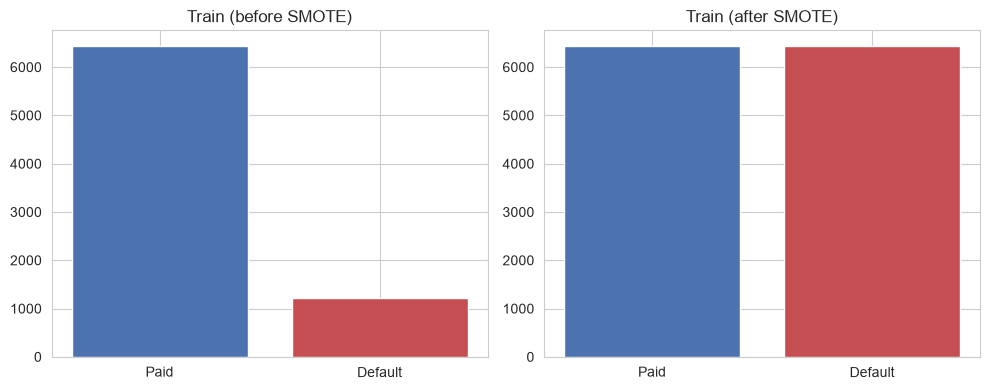

In [10]:
X = df_model.drop(columns=['not.fully.paid'])
y = df_model['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Before SMOTE:', np.bincount(y_train))
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_s, y_train)
print('After SMOTE:', np.bincount(y_train_bal))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['Paid', 'Default'], np.bincount(y_train), color=['#4C72B0', '#C44E52'])
ax[0].set_title('Train (before SMOTE)')
ax[1].bar(['Paid', 'Default'], np.bincount(y_train_bal), color=['#4C72B0', '#C44E52'])
ax[1].set_title('Train (after SMOTE)')
plt.tight_layout()
plt.show()

## 7. Deep Learning Model (Keras + TensorFlow)

In [11]:
model = keras.Sequential([
    layers.Input(shape=(X_train_bal.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='lending_club_default_nn')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Recall(name='recall')]
)
model.summary()

Model: "lending_club_default_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early = keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=8, restore_best_weights=True
)

history = model.fit(
    X_train_bal, y_train_bal,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

Epoch 1/50


  1/161 ━━━━━━━━━━━━━━━━━━━━ 2:26 917ms/step - accuracy: 0.4844 - auc: 0.4062 - loss: 0.7052 - recall: 0.2500

102/161 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - accuracy: 0.6294 - auc: 0.6143 - loss: 0.6430 - recall: 0.2301  

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6358 - auc: 0.6281 - loss: 0.6369 - recall: 0.2499 - val_accuracy: 0.3270 - val_auc: 0.0000e+00 - val_loss: 0.9043 - val_recall: 0.3270


Epoch 2/50


...

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - accuracy: 0.6735 - auc: 0.7011 - loss: 0.5988 - recall: 0.3810 - val_accuracy: 0.3988 - val_auc: 0.0000e+00 - val_loss: 0.8507 - val_recall: 0.3988


Epoch 9/50


  1/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7656 - auc: 0.7574 - loss: 0.5367 - recall: 0.5000

115/161 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step - accuracy: 0.6785 - auc: 0.7133 - loss: 0.5927 - recall: 0.3905

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.6753 - auc: 0.7081 - loss: 0.5945 - recall: 0.3862 - val_accuracy: 0.4082 - val_auc: 0.0000e+00 - val_loss: 0.8267 - val_recall: 0.4082


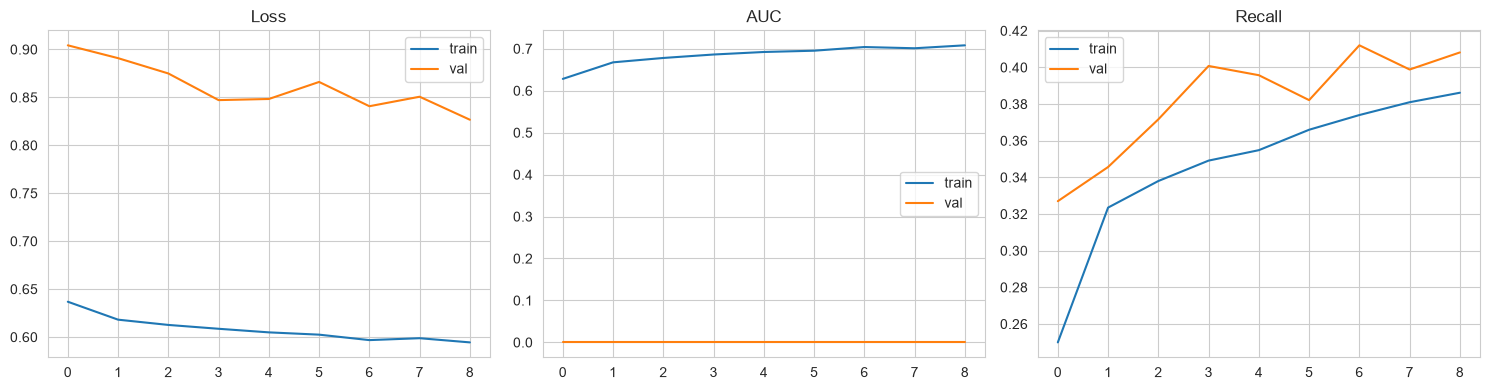

In [13]:
hist = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist['loss'], label='train')
axes[0].plot(hist['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(hist['auc'], label='train')
axes[1].plot(hist['val_auc'], label='val')
axes[1].set_title('AUC'); axes[1].legend()
axes[2].plot(hist['recall'], label='train')
axes[2].plot(hist['val_recall'], label='val')
axes[2].set_title('Recall'); axes[2].legend()
plt.tight_layout()
plt.show()

## 8. Evaluation on Test Set

In [14]:
y_prob = model.predict(X_test_s).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Not Fully Paid']))
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')

 1/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step


                precision    recall  f1-score   support

    Fully Paid       0.87      0.88      0.87      1609
Not Fully Paid       0.31      0.29      0.30       307

      accuracy                           0.78      1916
     macro avg       0.59      0.58      0.58      1916
  weighted avg       0.78      0.78      0.78      1916

Accuracy : 0.7834
Precision: 0.3099
Recall   : 0.2866
F1       : 0.2978
ROC-AUC  : 0.6668


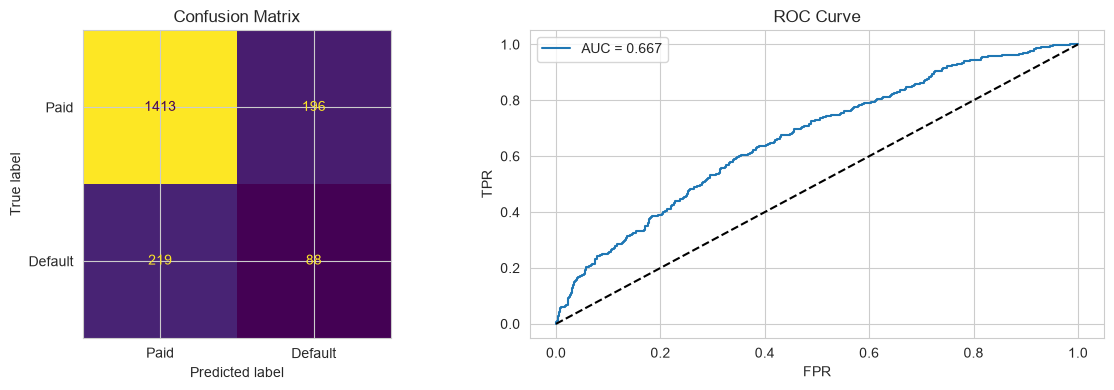

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Summary

1. **Feature transformation:** Encoded `purpose` with one-hot encoding.
2. **EDA:** Confirmed class imbalance; FICO, interest rate, and inquiries relate to default.
3. **Feature engineering:** Dropped strongly correlated predictors (|r| > 0.80) to reduce redundancy.
4. **Modeling:** Keras feed-forward network with Dropout; SMOTE on training data; EarlyStopping on validation AUC.
5. **Outcome:** Test metrics (Recall / AUC) reported above for default prediction.

**Deliverable:** `Lending_Club_Loan_Analysis.ipynb`